In [8]:
import os
import torch
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

# === Set device ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")

# === Load metadata ===
train_df = pd.read_csv("/content/train_metadata.csv")
val_df = pd.read_csv("/content/val_metadata.csv")

# === Create full image paths ===
train_df['path'] = "/content/split_photos/train/" + train_df['photo_id'].astype(str) + '.jpg'
val_df['path']   = "/content/split_photos/val/" + val_df['photo_id'].astype(str) + '.jpg'

# === Filter metadata to only include images that actually exist ===
def file_exists(path):
    return os.path.exists(path)

train_df = train_df[train_df['path'].apply(file_exists)].reset_index(drop=True)
val_df   = val_df[val_df['path'].apply(file_exists)].reset_index(drop=True)

print(f"✅ Filtered Train: {len(train_df)} rows")
print(f"✅ Filtered Val:   {len(val_df)} rows")

# === Label encoding ===
labels = sorted(train_df['label'].unique())
label2idx = {label: idx for idx, label in enumerate(labels)}
train_df['label_idx'] = train_df['label'].map(label2idx)
val_df['label_idx'] = val_df['label'].map(label2idx)

# === Transformations ===
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# === Custom Dataset ===
class PhotoDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_path = self.df.iloc[idx]['path']
        label = self.df.iloc[idx]['label_idx']
        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

# === Data Loaders ===
train_dataset = PhotoDataset(train_df, transform=transform)
val_dataset = PhotoDataset(val_df, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

# === Load pretrained EfficientNet ===
efficientnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
num_features = efficientnet.classifier[1].in_features
efficientnet.classifier[1] = nn.Linear(num_features, len(labels))
efficientnet.to(device)

# === Loss and Optimizer ===
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(efficientnet.parameters(), lr=1e-4)

# === Training Loop ===
num_epochs = 10

for epoch in range(num_epochs):
    efficientnet.train()
    train_loss = 0.0
    train_correct = 0
    total_train = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = efficientnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        total_train += labels.size(0)

        loop.set_postfix(loss=loss.item())

    avg_loss = train_loss / total_train
    train_acc = train_correct / total_train
    print(f"Train Loss: {avg_loss:.4f} | Train Accuracy: {train_acc:.4f}")

    # === Validation ===
    efficientnet.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = efficientnet(images)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    print(f"Validation Accuracy: {val_acc:.4f}\n")


✅ Using device: cuda
✅ Filtered Train: 17192 rows
✅ Filtered Val:   2146 rows


Epoch 1/10: 100%|██████████| 538/538 [01:31<00:00,  5.89it/s, loss=0.286]

Train Loss: 0.3777 | Train Accuracy: 0.8797


Validation Accuracy: 0.9292



Epoch 2/10: 100%|██████████| 538/538 [01:31<00:00,  5.90it/s, loss=1.14]

...

Train Loss: 0.0272 | Train Accuracy: 0.9911


Validation Accuracy: 0.9371



Epoch 10/10: 100%|██████████| 538/538 [01:31<00:00,  5.85it/s, loss=0.0392]

Train Loss: 0.0248 | Train Accuracy: 0.9918


Validation Accuracy: 0.9287



In [9]:
# Save model
torch.save(efficientnet.state_dict(), "efficientnet_yelp.pth")

# Download in Colab
from google.colab import files
files.download("efficientnet_yelp.pth")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

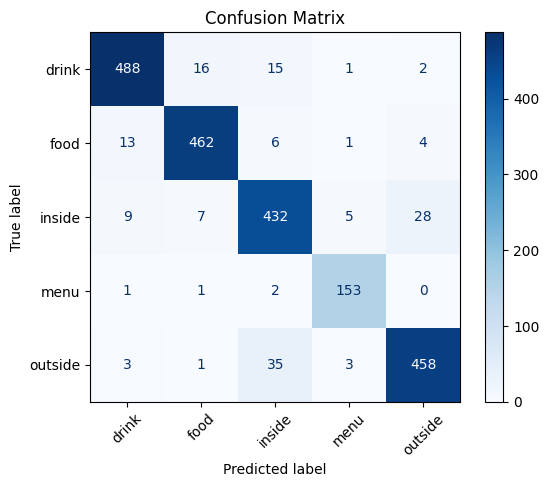


✅ Macro AUC Score: 0.9583


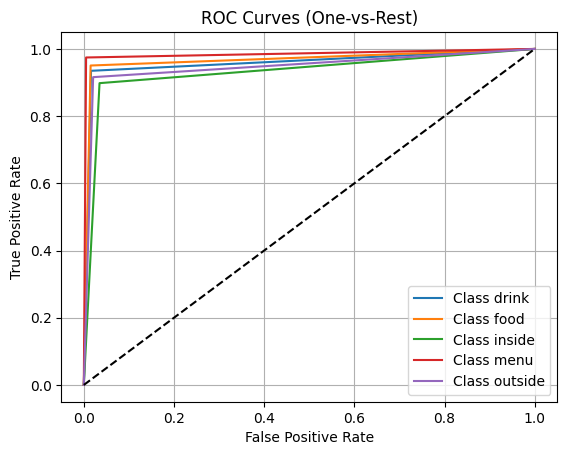

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

# === Load saved predictions and true labels ===
y_pred = np.load("/content/efficientnet_preds.npy")
y_true = np.load("/content/efficientnet_true.npy")

# === Class names (adjust if needed) ===
class_names = ['drink', 'food', 'inside', 'menu', 'outside']
n_classes = len(class_names)

# === Confusion Matrix ===
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

# === AUC Calculation ===
y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))
y_pred_bin = label_binarize(y_pred, classes=list(range(n_classes)))

# Compute AUC score
auc_score = roc_auc_score(y_true_bin, y_pred_bin, average='macro', multi_class='ovr')
print(f"\n✅ Macro AUC Score: {auc_score:.4f}")

# === ROC Curve (Macro Average) ===
fpr = dict()
tpr = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_bin[:, i])
    plt.plot(fpr[i], tpr[i], label=f"Class {class_names[i]}")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest)")
plt.legend()
plt.grid(True)
plt.show()


# LLM prompots--
-how can i train effecientNet Model using metadata

-give me confuison matrix and auc curve